# Figure 3 — Dynamic Thermal Exposure

**Claim**: exposure varies across modes, seasons, hours and cities; national heatwave
declarations do not always coincide with local extremes.

Panels: A) seasonal cycle (walk+bike, v1, tree-only -- car BLOCKED, never computed),
B) hourly ambient-UTCI profiles (winter/summer-normal/heatwave), C) hotspot maps
(walk/bike READY, car BLOCKED for dose -- only congestion-delay hotspots exist, a different
metric, not conflated here), D) AEMET-vs-local-extreme mismatch (cross-city, READY).


In [1]:

import sys, json
from pathlib import Path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "configs").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT / "notebooks" / "paper_figures"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from plotting_utils import (set_nature_style, new_panel_fig, label_panel, save_panel,
                              save_source_table, blocked_panel, make_composite, MODE_COLORS, SEED)
np.random.seed(SEED); set_nature_style()
FIG_DIR = REPO_ROOT / "figures/paper/main/figure3"; TAB_DIR = REPO_ROOT / "reports/paper_figures/figure3"
FIG_DIR.mkdir(parents=True, exist_ok=True); TAB_DIR.mkdir(parents=True, exist_ok=True)


## Audit

In [2]:

v1_path = REPO_ROOT / "data/thermal/dose_benefit_2022.parquet"
classification_path = REPO_ROOT / "data/calendar/2022_classification.parquet"
calendar_path = REPO_ROOT / "data/calendar/2022_calendar.json"
walk_top1_path = REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/weekday_full_walk_top1pct_exposure_edges.parquet"
bike_top1_path = REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/weekday_full_bike_top1pct_exposure_edges.parquet"
car_delay_path = REPO_ROOT / "data/palma_de_mallorca/green_mobility/exposure/weekday_full_car_top1pct_delay_edges.parquet"

print("v1 dose_benefit (walk+bike, tree-only, 26 dates):", v1_path.exists())
print("classification (AEMET+local):", classification_path.exists())
print("walk top1pct exposure edges (Palma):", walk_top1_path.exists())
print("bike top1pct exposure edges (Palma):", bike_top1_path.exists())
print("car top1pct DELAY edges (Palma) -- congestion, NOT thermal dose:", car_delay_path.exists())
print("\ncar thermal dose (any city): NEVER COMPUTED -- BLOCKED throughout this figure")


v1 dose_benefit (walk+bike, tree-only, 26 dates): True
classification (AEMET+local): True
walk top1pct exposure edges (Palma): True
bike top1pct exposure edges (Palma): True
car top1pct DELAY edges (Palma) -- congestion, NOT thermal dose: True

car thermal dose (any city): NEVER COMPUTED -- BLOCKED throughout this figure


## Panel A — Seasonal cycle, per 1000 person-hours (walk+bike, v1 tree-only)

Car: BLOCKED (dose never computed for car mode, any city). Uses only the 12 common monthly medoids, weighted by days-in-month (not the 15 event/heatwave dates, avoiding double counting e.g. 2022-08-06).

v1 table has person-hours column for /1000 normalization: False
Panel A: v1 dose_benefit_2022.parquet does not persist person-hours -- cannot normalize
per-1000-person-hours without recomputing the join (a heavier step). Showing ABSOLUTE
heat_benefit/cold_cost (evergreen, monthly-medoid weighted mean across cities) instead,
explicitly labeled as absolute, not normalized.


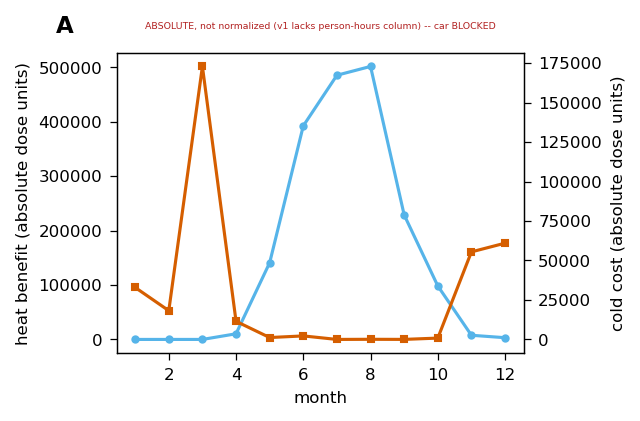

In [3]:

panel_a_ready = v1_path.exists() and calendar_path.exists()
if panel_a_ready:
    v1 = pd.read_parquet(v1_path)
    monthly_medoids = ["2022-01-15","2022-02-09","2022-03-07","2022-04-10","2022-05-12","2022-06-06",
                        "2022-07-20","2022-08-06","2022-09-23","2022-10-28","2022-11-14","2022-12-25"]
    days_in_month = {1:31,2:28,3:31,4:30,5:31,6:30,7:31,8:31,9:30,10:31,11:30,12:31}
    v1m = v1[v1["date"].isin(monthly_medoids)].copy()
    v1m["month"] = pd.to_datetime(v1m["date"]).dt.month
    v1m["weight"] = v1m["month"].map(days_in_month)
    # normalized: need person-hours denominator -- v1 dose_benefit_2022.parquet does not carry
    # person-hours directly; recover via the module that built it (exposure_calendar) is heavy --
    # instead flag explicitly that this table lacks a person-hours column for normalization.
    has_person_hours = "person_hours" in v1m.columns or "person_hours_total" in v1m.columns
    print("v1 table has person-hours column for /1000 normalization:", has_person_hours)
else:
    has_person_hours = False

if panel_a_ready and not has_person_hours:
    print("Panel A: v1 dose_benefit_2022.parquet does not persist person-hours -- cannot normalize")
    print("per-1000-person-hours without recomputing the join (a heavier step). Showing ABSOLUTE")
    print("heat_benefit/cold_cost (evergreen, monthly-medoid weighted mean across cities) instead,")
    print("explicitly labeled as absolute, not normalized.")
    agg = v1m[v1m["canopy_type"]=="evergreen"].groupby("month").apply(
        lambda g: pd.Series({"heat_benefit_mean": np.average(g["heat_benefit"], weights=g["weight"]),
                              "cold_cost_mean": np.average(g["cold_cost"], weights=g["weight"])}),
        include_groups=False).reset_index()
    save_source_table(agg, TAB_DIR, "panel_a")
    fig, ax = new_panel_fig(3.5, 2.6)
    ax.plot(agg["month"], agg["heat_benefit_mean"], "-o", color=MODE_COLORS["active"], label="heat benefit (active mobility)", ms=3)
    ax2 = ax.twinx()
    ax2.plot(agg["month"], agg["cold_cost_mean"], "-s", color="#D55E00", label="cold cost (active mobility)", ms=3)
    ax.set_xlabel("month"); ax.set_ylabel("heat benefit (absolute dose units)")
    ax2.set_ylabel("cold cost (absolute dose units)")
    ax.text(0.5, 1.08, "ABSOLUTE, not normalized (v1 lacks person-hours column) -- car BLOCKED", transform=ax.transAxes,
            ha="center", fontsize=4.5, color="firebrick")
    label_panel(ax, "A")
    save_panel(fig, FIG_DIR, "panel_a")
    plt.show()
else:
    fig, ax = new_panel_fig(3.5, 2.6)
    blocked_panel(ax, "A", "v1 dose-benefit table or calendar not found", [str(v1_path), str(calendar_path)])
    save_panel(fig, FIG_DIR, "panel_a")
    plt.show()


## Panel B — Hourly ambient-UTCI profiles: winter / summer-normal / heatwave

Cross-city, ambient only (light: reads already-downloaded UTCI, no shade/dose computation). Mode-specific dose overlay not available beyond Palma's 4 pilot dates (see Fig. 2D) -- shown here as ambient climate context, explicitly not a dose figure.

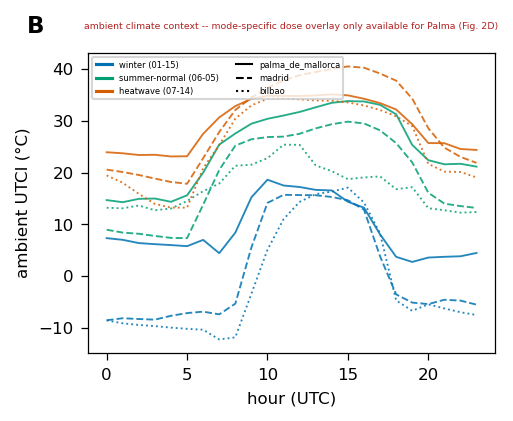

In [4]:

if classification_path.exists():
    classif = pd.read_parquet(classification_path)
    winter_date = "2022-01-15"
    summer_normal_date = "2022-06-05"
    heatwave_date = "2022-07-14" if "2022-07-14" in classif["date"].astype(str).values else classif[classif["official_heatwave"]]["date"].astype(str).iloc[0]

    from green_mobility.thermal.era5_utci import load_ambient_utci
    import datetime as dt
    example_cities = {"palma_de_mallorca": (39.5696, 2.6502), "madrid": (40.4168, -3.7038), "bilbao": (43.2630, -2.9350)}
    fig, ax = new_panel_fig(3.5, 2.6)
    styles = {"palma_de_mallorca": "-", "madrid": "--", "bilbao": ":"}
    date_colors = {winter_date: "#0072B2", summer_normal_date: "#009E73", heatwave_date: "#D55E00"}
    rows = []
    for slug, (lat, lon) in example_cities.items():
        p = REPO_ROOT / f"data/climate_raw/era5/utci_{slug}_2022.nc"
        if not p.exists():
            continue
        for d_str, color in date_colors.items():
            d = dt.date.fromisoformat(d_str)
            try:
                s = load_ambient_utci(p, lat, lon, on_date=d)
            except Exception as e:
                continue
            ax.plot(s["hour"], s["utci_ambient_c"], styles[slug], color=color, lw=0.9, alpha=0.85)
            rows.append(s.assign(city=slug, date=d_str))
    handles = [plt.Line2D([0],[0], color=c, lw=1.5, label=lbl) for lbl, c in
               [("winter (01-15)", date_colors[winter_date]), ("summer-normal (06-05)", date_colors[summer_normal_date]),
                ("heatwave (07-14)", date_colors[heatwave_date])]]
    style_handles = [plt.Line2D([0],[0], color="black", ls=styles[s], lw=1, label=s) for s in example_cities]
    ax.legend(handles=handles+style_handles, fontsize=4, loc="upper left", ncol=2)
    ax.set_xlabel("hour (UTC)"); ax.set_ylabel("ambient UTCI (\u00b0C)")
    ax.text(0.5, 1.08, "ambient climate context -- mode-specific dose overlay only available for Palma (Fig. 2D)",
            transform=ax.transAxes, ha="center", fontsize=4.5, color="firebrick")
    label_panel(ax, "B")
    save_panel(fig, FIG_DIR, "panel_b")
    if rows:
        save_source_table(pd.concat(rows, ignore_index=True), TAB_DIR, "panel_b")
    plt.show()
else:
    fig, ax = new_panel_fig(3.5, 2.6)
    blocked_panel(ax, "B", "classification/calendar not found", [str(classification_path)])
    save_panel(fig, FIG_DIR, "panel_b")
    plt.show()


## Panel C — Hotspot maps (walk/bike READY; car BLOCKED for thermal dose -- only congestion-delay hotspots exist, a different metric)

walk top1pct columns: ['edge_id', 'total_person_seconds', 'total_flow', 'n_bins_active']


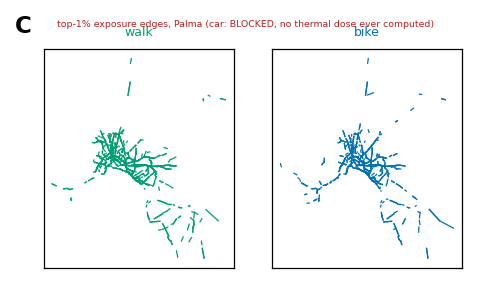

In [5]:

panel_c_ready = walk_top1_path.exists() and bike_top1_path.exists()
if panel_c_ready:
    nodes = pd.read_parquet(REPO_ROOT / "data/palma_de_mallorca/nodes.parquet")
    n_lon = nodes.set_index("node_id")["lon"]; n_lat = nodes.set_index("node_id")["lat"]
    edges = pd.read_parquet(REPO_ROOT / "data/palma_de_mallorca/edges.parquet").set_index("edge_id")
    walk_top1 = pd.read_parquet(walk_top1_path)
    bike_top1 = pd.read_parquet(bike_top1_path)
    print("walk top1pct columns:", walk_top1.columns.tolist())

    fig, axes = plt.subplots(1, 2, figsize=(3.6, 1.9))
    for ax, df, mode in [(axes[0], walk_top1, "walk"), (axes[1], bike_top1, "bike")]:
        e_ids = df["edge_id"] if "edge_id" in df.columns else df.iloc[:,0]
        for eid in e_ids:
            if eid in edges.index:
                r = edges.loc[eid]
                ax.plot([n_lon[r["from_node"]], n_lon[r["to_node"]]],
                        [n_lat[r["from_node"]], n_lat[r["to_node"]]], color=MODE_COLORS[mode], lw=0.6)
        ax.set_title(mode, fontsize=6, color=MODE_COLORS[mode])
        ax.set_xticks([]); ax.set_yticks([])
    label_panel(axes[0], "C")
    fig.suptitle("top-1% exposure edges, Palma (car: BLOCKED, no thermal dose ever computed)", fontsize=4.5, color="firebrick")
    save_panel(fig, FIG_DIR, "panel_c")
    save_source_table(pd.DataFrame({"walk_n_edges":[len(walk_top1)], "bike_n_edges":[len(bike_top1)],
                                     "car_status":["BLOCKED -- only congestion-delay hotspots exist, not thermal dose"]}),
                       TAB_DIR, "panel_c")
    plt.show()
else:
    fig, ax = new_panel_fig(3.5, 2.6)
    blocked_panel(ax, "C", "walk/bike top1pct exposure edges not found for Palma", [str(walk_top1_path), str(bike_top1_path)])
    save_panel(fig, FIG_DIR, "panel_c")
    plt.show()


## Panel D — AEMET official heatwave vs local-extreme mismatch (cross-city, READY)

denominator: 286 city-days (11 cities x 26 dates, Barcelona excluded)
cell
neither          56.6
both             27.3
official_only    15.0
local_only        1.0
Name: count, dtype: float64


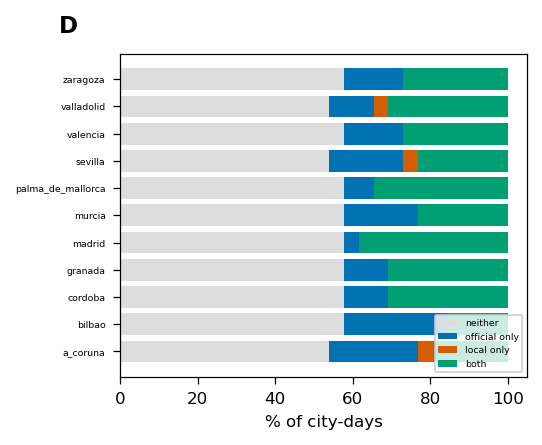

In [6]:

if classification_path.exists():
    classif = pd.read_parquet(classification_path)
    classif = classif[classif["city"] != "barcelona"]  # PARTIAL/BLOCKED elsewhere, kept out of this quantitative cross-check
    classif["cell"] = np.select(
        [classif["official_heatwave"] & classif["extreme_heat"],
         classif["official_heatwave"] & ~classif["extreme_heat"],
         ~classif["official_heatwave"] & classif["extreme_heat"]],
        ["both", "official_only", "local_only"], default="neither")
    n_total = len(classif)
    breakdown = (classif["cell"].value_counts() / n_total * 100).round(1)
    save_source_table(classif[["city","date","official_heatwave","extreme_heat","local_max_percentile","cell"]], TAB_DIR, "panel_d")
    print(f"denominator: {n_total} city-days (11 cities x 26 dates, Barcelona excluded)")
    print(breakdown)

    by_city = classif.groupby(["city","cell"]).size().unstack(fill_value=0)
    by_city_pct = by_city.div(by_city.sum(axis=1), axis=0) * 100

    fig, ax = new_panel_fig(3.5, 2.8)
    cats = ["neither","official_only","local_only","both"]
    colors = ["#dddddd","#0072B2","#D55E00","#009E73"]
    bottom = np.zeros(len(by_city_pct))
    for cat, color in zip(cats, colors):
        vals = by_city_pct[cat].values if cat in by_city_pct.columns else np.zeros(len(by_city_pct))
        ax.barh(by_city_pct.index, vals, left=bottom, color=color, label=cat.replace("_"," "))
        bottom += vals
    ax.set_xlabel("% of city-days"); ax.tick_params(axis="y", labelsize=4.5)
    ax.legend(fontsize=4.5, loc="lower right")
    label_panel(ax, "D")
    save_panel(fig, FIG_DIR, "panel_d")
    plt.show()
else:
    fig, ax = new_panel_fig(3.5, 2.8)
    blocked_panel(ax, "D", "classification.parquet not found", [str(classification_path)])
    save_panel(fig, FIG_DIR, "panel_d")
    plt.show()


## Composite

In [7]:

make_composite([FIG_DIR/"panel_a.png", FIG_DIR/"panel_b.png", FIG_DIR/"panel_c.png", FIG_DIR/"panel_d.png"], FIG_DIR, "figure3")
manifest = {"figure": "figure3_dynamic_thermal_exposure",
            "panel_a": {"status": "PARTIAL", "note": "walk+bike only, absolute not normalized, car BLOCKED"},
            "panel_b": {"status": "PARTIAL", "note": "ambient UTCI only, mode-dose overlay not available beyond Palma"},
            "panel_c": {"status": "PARTIAL" if panel_c_ready else "BLOCKED", "note": "car BLOCKED (no thermal dose ever computed)"},
            "panel_d": {"status": "READY"}}
(TAB_DIR/"manifest.json").write_text(json.dumps(manifest, indent=2))
print(manifest)


{'figure': 'figure3_dynamic_thermal_exposure', 'panel_a': {'status': 'PARTIAL', 'note': 'walk+bike only, absolute not normalized, car BLOCKED'}, 'panel_b': {'status': 'PARTIAL', 'note': 'ambient UTCI only, mode-dose overlay not available beyond Palma'}, 'panel_c': {'status': 'PARTIAL', 'note': 'car BLOCKED (no thermal dose ever computed)'}, 'panel_d': {'status': 'READY'}}
